In [1]:
# Cell 1 — Configuration and frozen dataset loading

from pathlib import Path
import json
import random
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/homes/mxqasim/Chocolathon")
SYNTHETIC_ROOT = PROJECT_ROOT / "data/synthetic_slots/v1"
DATASET_MANIFEST = SYNTHETIC_ROOT / "dataset/synthetic_slot_manifest.csv"
EXPERIMENT_DIR = PROJECT_ROOT / "data/experiments/synthetic_slot_embeddings_v1"
OUTPUT_DIR = EXPERIMENT_DIR / "outputs"
DEPLOYMENT_DIR = EXPERIMENT_DIR / "deployment"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEPLOYMENT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

slot_manifest = pd.read_csv(DATASET_MANIFEST)
slot_manifest["image_path"] = slot_manifest["relative_path"].map(lambda path: str(PROJECT_ROOT / Path(path)))

missing_images = slot_manifest.loc[~slot_manifest["image_path"].map(lambda path: Path(path).exists())]
split_summary = slot_manifest.groupby(["split", "label_type"]).size().rename("samples").reset_index()

print("Project root:", PROJECT_ROOT)
print("Dataset manifest:", DATASET_MANIFEST)
print("Experiment directory:", EXPERIMENT_DIR)
print("=" * 72)
print("SYNTHETIC SLOT DATASET")
print("=" * 72)
print("Samples:", len(slot_manifest))
print("Classes:", slot_manifest["flavor_id"].nunique())
print("Chocolate flavors:", slot_manifest.loc[slot_manifest["label_type"].eq("occupied"), "flavor_id"].nunique())
print("Source boxes:", slot_manifest["empty_source_file"].nunique())
print("Missing images:", len(missing_images))
display(split_summary)

assert len(slot_manifest) == 3718
assert slot_manifest["flavor_id"].nunique() == 34
assert len(missing_images) == 0
assert slot_manifest["sample_id"].is_unique

print("\nPASS: frozen synthetic-slot dataset loaded successfully")

Project root: /homes/mxqasim/Chocolathon
Dataset manifest: /homes/mxqasim/Chocolathon/data/synthetic_slots/v1/dataset/synthetic_slot_manifest.csv
Experiment directory: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1
SYNTHETIC SLOT DATASET
Samples: 3718
Classes: 34
Chocolate flavors: 33
Source boxes: 16
Missing images: 0


,split,label_type,samples
0,train,empty,316
1,train,occupied,2640
2,validation,empty,102
3,validation,occupied,660



PASS: frozen synthetic-slot dataset loaded successfully


In [2]:
# Cell 2 — Prepare the frozen EfficientNet-B0 embedding backbone

from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

torch.manual_seed(RANDOM_SEED)
torch.set_num_threads(min(8, max(1, torch.get_num_threads())))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = EfficientNet_B0_Weights.IMAGENET1K_V1
transform = weights.transforms()

class SlotDataset(Dataset):
    def __init__(self, manifest, transform):
        self.manifest = manifest.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):
        with Image.open(self.manifest.loc[index, "image_path"]) as image:
            tensor = self.transform(image.convert("RGB"))
        return tensor, index

slot_dataset = SlotDataset(slot_manifest, transform)
slot_loader = DataLoader(slot_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=device.type == "cuda")

embedding_model = efficientnet_b0(weights=weights)
embedding_model.classifier = torch.nn.Identity()
embedding_model.eval().to(device)

with torch.inference_mode():
    test_embedding = F.normalize(embedding_model(slot_dataset[0][0].unsqueeze(0).to(device)), dim=1)

print("PyTorch:", torch.__version__)
print("Device:", device)
print("Images:", len(slot_dataset))
print("Batches:", len(slot_loader))
print("Embedding shape:", tuple(test_embedding.shape))
print("Embedding dimension:", test_embedding.shape[1])
print("Embedding norm:", test_embedding.norm(dim=1).item())
print("Trainable parameters:", sum(parameter.numel() for parameter in embedding_model.parameters() if parameter.requires_grad))
print("PASS: frozen EfficientNet-B0 embedding backbone is ready")

/homes/mxqasim/Chocolathon/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
/homes/mxqasim/Chocolathon/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


PyTorch: 2.7.1+cpu
Device: cpu
Images: 3718
Batches: 117
Embedding shape: (1, 1280)
Embedding dimension: 1280
Embedding norm: 1.0
Trainable parameters: 4007548
PASS: frozen EfficientNet-B0 embedding backbone is ready


In [3]:
# Cell 3 — Extract and cache all slot embeddings

embedding_batches, index_batches = [], []

with torch.inference_mode():
    for batch_number, (images, indices) in enumerate(slot_loader, start=1):
        embeddings = F.normalize(embedding_model(images.to(device, non_blocking=True)), dim=1)
        embedding_batches.append(embeddings.cpu().numpy().astype(np.float32))
        index_batches.append(indices.numpy())

        if batch_number == 1 or batch_number % 20 == 0 or batch_number == len(slot_loader):
            print(f"Processed batch {batch_number}/{len(slot_loader)}")

slot_embeddings = np.concatenate(embedding_batches)
embedding_indices = np.concatenate(index_batches)

assert np.array_equal(embedding_indices, np.arange(len(slot_manifest)))
assert slot_embeddings.shape == (3718, 1280)
assert np.isfinite(slot_embeddings).all()
assert np.allclose(np.linalg.norm(slot_embeddings, axis=1), 1.0, atol=1e-5)

embedding_index = slot_manifest.copy()
embedding_index.insert(0, "embedding_row", np.arange(len(embedding_index)))

EMBEDDING_CACHE = OUTPUT_DIR / "efficientnet_b0_slot_embeddings.npz"
EMBEDDING_INDEX = OUTPUT_DIR / "embedding_index.csv"

np.savez_compressed(
    EMBEDDING_CACHE,
    embeddings=slot_embeddings,
    sample_ids=embedding_index["sample_id"].astype(str).to_numpy(),
)
embedding_index.to_csv(EMBEDDING_INDEX, index=False)

print("\nEmbedding matrix:", slot_embeddings.shape)
print("Data type:", slot_embeddings.dtype)
print("Minimum norm:", np.linalg.norm(slot_embeddings, axis=1).min())
print("Maximum norm:", np.linalg.norm(slot_embeddings, axis=1).max())
print("Finite values:", np.isfinite(slot_embeddings).all())
print("Cache size:", round(EMBEDDING_CACHE.stat().st_size / 1024**2, 2), "MB")
print("Embedding cache:", EMBEDDING_CACHE)
print("Index manifest:", EMBEDDING_INDEX)
print("\nPASS: all 3,718 slot embeddings were extracted and cached")

Processed batch 1/117
Processed batch 20/117
Processed batch 40/117
Processed batch 60/117
Processed batch 80/117
Processed batch 100/117
Processed batch 117/117

Embedding matrix: (3718, 1280)
Data type: float32
Minimum norm: 0.9999998
Maximum norm: 1.0000002
Finite values: True
Cache size: 16.84 MB
Embedding cache: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/outputs/efficientnet_b0_slot_embeddings.npz
Index manifest: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/outputs/embedding_index.csv

PASS: all 3,718 slot embeddings were extracted and cached


In [4]:
# Cell 4 — Build 34 training prototypes and predict validation samples

from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix

train_manifest = embedding_index[embedding_index["split"].eq("train")].copy()
validation_manifest = embedding_index[embedding_index["split"].eq("validation")].copy()

class_ids = sorted(train_manifest["flavor_id"].unique())
class_to_index = {class_id: index for index, class_id in enumerate(class_ids)}
class_name_lookup = embedding_index.drop_duplicates("flavor_id").set_index("flavor_id")["flavor_name"].to_dict()

prototype_rows = []
for class_id in class_ids:
    rows = train_manifest.loc[train_manifest["flavor_id"].eq(class_id), "embedding_row"].to_numpy()
    prototype = slot_embeddings[rows].mean(axis=0)
    prototype_rows.append(prototype / np.linalg.norm(prototype))

class_prototypes = np.stack(prototype_rows).astype(np.float32)
validation_embeddings = slot_embeddings[validation_manifest["embedding_row"].to_numpy()]
validation_scores = validation_embeddings @ class_prototypes.T
validation_ranking = np.argsort(-validation_scores, axis=1)

validation_truth = validation_manifest["flavor_id"].astype(str).to_numpy()
validation_predictions = np.asarray(class_ids)[validation_ranking[:, 0]]
validation_top3 = np.asarray(class_ids)[validation_ranking[:, :3]]
validation_top1_scores = validation_scores[np.arange(len(validation_scores)), validation_ranking[:, 0]]
validation_top2_scores = validation_scores[np.arange(len(validation_scores)), validation_ranking[:, 1]]
validation_margins = validation_top1_scores - validation_top2_scores

prediction_rows = []
for index, row in validation_manifest.reset_index(drop=True).iterrows():
    ranked_ids = validation_top3[index]
    prediction_rows.append({
        "sample_id": row["sample_id"],
        "relative_path": row["relative_path"],
        "true_flavor_id": row["flavor_id"],
        "true_flavor_name": row["flavor_name"],
        "predicted_flavor_id": validation_predictions[index],
        "predicted_flavor_name": class_name_lookup[validation_predictions[index]],
        "top1_similarity": validation_top1_scores[index],
        "similarity_margin": validation_margins[index],
        "top2_flavor_id": ranked_ids[1],
        "top3_flavor_id": ranked_ids[2],
        "top3_correct": row["flavor_id"] in ranked_ids,
        "label_type": row["label_type"],
        "empty_source_file": row["empty_source_file"],
        "box_size": row["box_size"],
        "extraction_method": row["extraction_method"],
    })

validation_predictions_df = pd.DataFrame(prediction_rows)

PROTOTYPE_FILE = OUTPUT_DIR / "efficientnet_b0_slot_class_prototypes.npz"
PREDICTION_FILE = OUTPUT_DIR / "validation_prototype_predictions.csv"

np.savez_compressed(PROTOTYPE_FILE, prototypes=class_prototypes, class_ids=np.asarray(class_ids))
validation_predictions_df.to_csv(PREDICTION_FILE, index=False)

print("Training samples:", len(train_manifest))
print("Validation samples:", len(validation_manifest))
print("Classes:", len(class_ids))
print("Prototype matrix:", class_prototypes.shape)
print("Predictions:", PREDICTION_FILE)
print("Prototypes:", PROTOTYPE_FILE)
print("PASS: validation predictions created")

Training samples: 2956
Validation samples: 762
Classes: 34
Prototype matrix: (34, 1280)
Predictions: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/outputs/validation_prototype_predictions.csv
Prototypes: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/outputs/efficientnet_b0_slot_class_prototypes.npz
PASS: validation predictions created


In [5]:
# Cell 5 — Evaluate the slot classifier at all decision levels

top1_accuracy = accuracy_score(validation_truth, validation_predictions)
top3_accuracy = validation_predictions_df["top3_correct"].mean()
macro_f1 = f1_score(validation_truth, validation_predictions, labels=class_ids, average="macro", zero_division=0)

true_occupied = validation_truth != "empty"
predicted_occupied = validation_predictions != "empty"
occupancy_accuracy = accuracy_score(true_occupied, predicted_occupied)
occupancy_matrix = confusion_matrix(true_occupied, predicted_occupied, labels=[False, True])
tn, fp, fn, tp = occupancy_matrix.ravel()
occupancy_precision = tp / (tp + fp) if tp + fp else 0
occupancy_recall = tp / (tp + fn) if tp + fn else 0
occupancy_f1 = 2 * occupancy_precision * occupancy_recall / (occupancy_precision + occupancy_recall) if occupancy_precision + occupancy_recall else 0

empty_mask = validation_truth == "empty"
occupied_mask = ~empty_mask
empty_accuracy = np.mean(validation_predictions[empty_mask] == validation_truth[empty_mask])
occupied_flavor_top1 = np.mean(validation_predictions[occupied_mask] == validation_truth[occupied_mask])
occupied_flavor_top3 = np.mean([truth in predictions for truth, predictions in zip(validation_truth[occupied_mask], validation_top3[occupied_mask])])

precision, recall, class_f1, support = precision_recall_fscore_support(
    validation_truth, validation_predictions, labels=class_ids, zero_division=0
)

class_metrics = pd.DataFrame({
    "flavor_id": class_ids,
    "flavor_name": [class_name_lookup[class_id] for class_id in class_ids],
    "precision": precision,
    "recall": recall,
    "f1": class_f1,
    "support": support,
}).sort_values(["f1", "support"])

overall_metrics = pd.DataFrame([{
    "combined_top1_accuracy": top1_accuracy,
    "combined_top3_accuracy": top3_accuracy,
    "combined_macro_f1": macro_f1,
    "occupancy_accuracy": occupancy_accuracy,
    "occupancy_precision": occupancy_precision,
    "occupancy_recall": occupancy_recall,
    "occupancy_f1": occupancy_f1,
    "empty_accuracy": empty_accuracy,
    "occupied_flavor_top1": occupied_flavor_top1,
    "occupied_flavor_top3": occupied_flavor_top3,
    "validation_samples": len(validation_truth),
}])

METRICS_FILE = OUTPUT_DIR / "validation_prototype_metrics.csv"
CLASS_METRICS_FILE = OUTPUT_DIR / "validation_class_metrics.csv"
overall_metrics.to_csv(METRICS_FILE, index=False)
class_metrics.to_csv(CLASS_METRICS_FILE, index=False)

print("=" * 72)
print("SYNTHETIC SLOT PROTOTYPE EVALUATION")
print("=" * 72)
print("Combined top-1 accuracy:", round(top1_accuracy, 4))
print("Combined top-3 accuracy:", round(top3_accuracy, 4))
print("Combined macro-F1:", round(macro_f1, 4))
print()
print("Occupancy accuracy:", round(occupancy_accuracy, 4))
print("Occupancy precision:", round(occupancy_precision, 4))
print("Occupancy recall:", round(occupancy_recall, 4))
print("Occupancy F1:", round(occupancy_f1, 4))
print("Occupancy confusion matrix [[TN, FP], [FN, TP]]:")
print(occupancy_matrix)
print()
print("Empty-slot accuracy:", round(empty_accuracy, 4))
print("Occupied flavor top-1:", round(occupied_flavor_top1, 4))
print("Occupied flavor top-3:", round(occupied_flavor_top3, 4))
print("Top-1 errors:", int((validation_truth != validation_predictions).sum()))
print()
display(overall_metrics)
display(class_metrics)
WWWWWW
print("Metrics:", METRICS_FILE)
print("Class metrics:", CLASS_METRICS_FILE)

SYNTHETIC SLOT PROTOTYPE EVALUATION
Combined top-1 accuracy: 0.9987
Combined top-3 accuracy: 1.0
Combined macro-F1: 0.9991

Occupancy accuracy: 0.9987
Occupancy precision: 0.9985
Occupancy recall: 1.0
Occupancy F1: 0.9992
Occupancy confusion matrix [[TN, FP], [FN, TP]]:
[[101   1]
 [  0 660]]

Empty-slot accuracy: 0.9902
Occupied flavor top-1: 1.0
Occupied flavor top-3: 1.0
Top-1 errors: 1



,combined_top1_accuracy,combined_top3_accuracy,combined_macro_f1,occupancy_accuracy,occupancy_precision,occupancy_recall,occupancy_f1,empty_accuracy,occupied_flavor_top1,occupied_flavor_top3,validation_samples
0,0.998688,1.0,0.999138,0.998688,0.998487,1.0,0.999243,0.990196,1.0,1.0,762


,flavor_id,flavor_name,precision,recall,f1,support
19,truffle_grey_salt_caramel,Grey Salt Caramel,0.952381,1.000000,0.975610,20
6,empty,Empty,1.000000,0.990196,0.995074,102
0,cocoashot_amaretto,Amaretto,1.000000,1.000000,1.000000,20
1,cocoashot_bourbon,Bourbon,1.000000,1.000000,1.000000,20
2,cocoashot_chocolate_cake,Chocolate Cake,1.000000,1.000000,1.000000,20
3,cocoashot_old_fashioned,Old Fashioned,1.000000,1.000000,1.000000,20
4,cocoashot_tequila,Tequila,1.000000,1.000000,1.000000,20
5,cocoashot_whiskey,Whiskey,1.000000,1.000000,1.000000,20
7,truffle_amaretto,Amaretto,1.000000,1.000000,1.000000,20
8,truffle_bananas_foster,Bananas Foster,1.000000,1.000000,1.000000,20


NameError: name 'WWWWWW' is not defined

In [6]:
print("Metrics:", METRICS_FILE)
print("Class metrics:", CLASS_METRICS_FILE)
print("\nPASS: synthetic validation evaluation completed")

Metrics: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/outputs/validation_prototype_metrics.csv
Class metrics: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/outputs/validation_class_metrics.csv

PASS: synthetic validation evaluation completed


In [1]:
# Cell 6 — Restore saved embedding experiment after kernel restart

from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/homes/mxqasim/Chocolathon")
EXPERIMENT_DIR = PROJECT_ROOT / "data/experiments/synthetic_slot_embeddings_v1"
OUTPUT_DIR = EXPERIMENT_DIR / "outputs"

EMBEDDING_CACHE = OUTPUT_DIR / "efficientnet_b0_slot_embeddings.npz"
EMBEDDING_INDEX = OUTPUT_DIR / "embedding_index.csv"
PROTOTYPE_FILE = OUTPUT_DIR / "efficientnet_b0_slot_class_prototypes.npz"
PREDICTION_FILE = OUTPUT_DIR / "validation_prototype_predictions.csv"
METRICS_FILE = OUTPUT_DIR / "validation_prototype_metrics.csv"
CLASS_METRICS_FILE = OUTPUT_DIR / "validation_class_metrics.csv"

embedding_cache = np.load(EMBEDDING_CACHE, allow_pickle=False)
prototype_cache = np.load(PROTOTYPE_FILE, allow_pickle=False)

slot_embeddings = embedding_cache["embeddings"]
embedding_index = pd.read_csv(EMBEDDING_INDEX)
class_prototypes = prototype_cache["prototypes"]
class_ids = prototype_cache["class_ids"].astype(str).tolist()
validation_predictions_df = pd.read_csv(PREDICTION_FILE)
overall_metrics = pd.read_csv(METRICS_FILE)
class_metrics = pd.read_csv(CLASS_METRICS_FILE)

print("Embeddings:", slot_embeddings.shape)
print("Prototypes:", class_prototypes.shape)
print("Predictions:", len(validation_predictions_df))
print("Classes:", len(class_ids))
display(overall_metrics)
print("PASS: experiment restored entirely from saved artifacts")

Embeddings: (3718, 1280)
Prototypes: (34, 1280)
Predictions: 762
Classes: 34


,combined_top1_accuracy,combined_top3_accuracy,combined_macro_f1,occupancy_accuracy,occupancy_precision,occupancy_recall,occupancy_f1,empty_accuracy,occupied_flavor_top1,occupied_flavor_top3,validation_samples
0,0.998688,1.0,0.999138,0.998688,0.998487,1.0,0.999243,0.990196,1.0,1.0,762


PASS: experiment restored entirely from saved artifacts


Validation samples: 762
Top-1 errors: 1


,sample_id,true_flavor_name,predicted_flavor_name,top1_similarity,top2_similarity,similarity_margin,empty_source_file,box_size
669,IMG_2023_r01_c04,Empty,Grey Salt Caramel,0.458815,0.454516,0.004299,IMG_2023.jpg,16


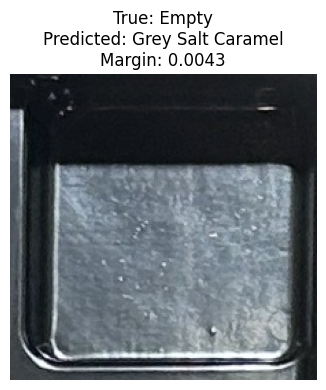

In [3]:
# Cell 7B — Display and visualize validation errors

error_columns = [
    "sample_id", "flavor_name", "predicted_flavor_name",
    "top1_similarity", "top2_similarity", "similarity_margin",
    "empty_source_file", "box_size"
]

print("Validation samples:", len(validation_analysis))
print("Top-1 errors:", len(errors))
display(errors[error_columns].rename(columns={"flavor_name": "true_flavor_name"}))

if len(errors):
    fig, axes = plt.subplots(1, len(errors), figsize=(4 * len(errors), 4))
    axes = np.atleast_1d(axes)

    for axis, (_, row) in zip(axes, errors.iterrows()):
        with Image.open(PROJECT_ROOT / Path(row["relative_path"])) as image:
            axis.imshow(image.convert("RGB"))

        axis.set_title(
            f"True: {row['flavor_name']}\n"
            f"Predicted: {row['predicted_flavor_name']}\n"
            f"Margin: {row['similarity_margin']:.4f}"
        )
        axis.axis("off")

    plt.tight_layout()
    plt.show()

In [4]:
# Cell 8 — Robustness breakdowns

def summarize_group(group):
    true_ids = group["flavor_id"].astype(str)
    predicted_ids = group["predicted_flavor_id"].astype(str)
    true_occupied = true_ids.ne("empty")
    predicted_occupied = predicted_ids.ne("empty")

    return pd.Series({
        "samples": len(group),
        "occupied_samples": int(true_occupied.sum()),
        "empty_samples": int((~true_occupied).sum()),
        "top1_accuracy": np.mean(true_ids == predicted_ids),
        "occupancy_accuracy": np.mean(true_occupied == predicted_occupied),
        "errors": int(np.sum(true_ids != predicted_ids)),
    })

box_size_metrics = validation_analysis.groupby("box_size").apply(summarize_group).reset_index()
source_box_metrics = validation_analysis.groupby(["empty_source_file", "box_size"]).apply(summarize_group).reset_index()

occupied_analysis = validation_analysis[validation_analysis["label_type"].eq("occupied")].copy()
extraction_metrics = occupied_analysis.groupby("extraction_method").apply(summarize_group).reset_index()
donor_metrics = occupied_analysis.groupby(["donor_sample_id", "extraction_method"]).apply(summarize_group).reset_index()

BOX_SIZE_METRICS = OUTPUT_DIR / "validation_metrics_by_box_size.csv"
SOURCE_BOX_METRICS = OUTPUT_DIR / "validation_metrics_by_source_box.csv"
EXTRACTION_METRICS = OUTPUT_DIR / "validation_metrics_by_extraction_method.csv"
DONOR_METRICS = OUTPUT_DIR / "validation_metrics_by_donor.csv"

box_size_metrics.to_csv(BOX_SIZE_METRICS, index=False)
source_box_metrics.to_csv(SOURCE_BOX_METRICS, index=False)
extraction_metrics.to_csv(EXTRACTION_METRICS, index=False)
donor_metrics.to_csv(DONOR_METRICS, index=False)

print("PERFORMANCE BY BOX SIZE")
display(box_size_metrics)

print("PERFORMANCE BY VALIDATION SOURCE BOX")
display(source_box_metrics)

print("OCCUPIED-FLAVOR PERFORMANCE BY EXTRACTION METHOD")
display(extraction_metrics)

print("Lowest-performing donors:")
display(donor_metrics.sort_values(["top1_accuracy", "samples"]).head(15))

print("PASS: robustness breakdowns saved")

PERFORMANCE BY BOX SIZE


/tmp/ipykernel_1924044/3926574459.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  box_size_metrics = validation_analysis.groupby("box_size").apply(summarize_group).reset_index()
/tmp/ipykernel_1924044/3926574459.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  source_box_metrics = validation_analysis.groupby(["empty_source_file", "box_size"]).apply(summarize_group).reset_index()
/tmp/ipykernel_1924044/392657

,box_size,samples,occupied_samples,empty_samples,top1_accuracy,occupancy_accuracy,errors
0,6,171.0,165.0,6.0,1.000000,1.000000,0.0
1,16,181.0,165.0,16.0,0.994475,0.994475,1.0
2,30,195.0,165.0,30.0,1.000000,1.000000,0.0
3,50,215.0,165.0,50.0,1.000000,1.000000,0.0


PERFORMANCE BY VALIDATION SOURCE BOX


,empty_source_file,box_size,samples,occupied_samples,empty_samples,top1_accuracy,occupancy_accuracy,errors
0,IMG_2020.jpg,6,171.0,165.0,6.0,1.000000,1.000000,0.0
1,IMG_2023.jpg,16,181.0,165.0,16.0,0.994475,0.994475,1.0
2,IMG_2030.jpg,30,195.0,165.0,30.0,1.000000,1.000000,0.0
3,IMG_2034.jpg,50,215.0,165.0,50.0,1.000000,1.000000,0.0


OCCUPIED-FLAVOR PERFORMANCE BY EXTRACTION METHOD


,extraction_method,samples,occupied_samples,empty_samples,top1_accuracy,occupancy_accuracy,errors
0,expanded_isnet,80.0,80.0,0.0,1.0,1.0,0.0
1,expanded_u2net,400.0,400.0,0.0,1.0,1.0,0.0
2,manual_polygon,180.0,180.0,0.0,1.0,1.0,0.0


Lowest-performing donors:


,donor_sample_id,extraction_method,samples,occupied_samples,empty_samples,top1_accuracy,occupancy_accuracy,errors
0,IMG_1959_c020,expanded_u2net,20.0,20.0,0.0,1.0,1.0,0.0
1,IMG_1960_c010,expanded_isnet,20.0,20.0,0.0,1.0,1.0,0.0
2,IMG_1961_c001,manual_polygon,20.0,20.0,0.0,1.0,1.0,0.0
3,IMG_1963_c011,expanded_u2net,20.0,20.0,0.0,1.0,1.0,0.0
4,IMG_1964_c006,expanded_u2net,20.0,20.0,0.0,1.0,1.0,0.0
5,IMG_1965_c026,expanded_isnet,20.0,20.0,0.0,1.0,1.0,0.0
6,IMG_1966_c012,expanded_u2net,20.0,20.0,0.0,1.0,1.0,0.0
7,IMG_1967_c004,manual_polygon,20.0,20.0,0.0,1.0,1.0,0.0
8,IMG_1968_c007,expanded_u2net,20.0,20.0,0.0,1.0,1.0,0.0
9,IMG_1969_c016,expanded_u2net,20.0,20.0,0.0,1.0,1.0,0.0


PASS: robustness breakdowns saved


In [5]:
# Cell 9 — Measure accuracy versus automatic-decision coverage

threshold_rows = []

for threshold in [0.000, 0.005, 0.010, 0.020, 0.030, 0.050, 0.075, 0.100]:
    confident = validation_analysis["similarity_margin"] >= threshold
    reviewed = ~confident
    correct = validation_analysis["correct"]

    threshold_rows.append({
        "margin_threshold": threshold,
        "confident_samples": int(confident.sum()),
        "review_samples": int(reviewed.sum()),
        "automatic_coverage": confident.mean(),
        "confident_accuracy": correct[confident].mean() if confident.any() else np.nan,
        "errors_sent_to_review": int((~correct & reviewed).sum()),
        "errors_left_confident": int((~correct & confident).sum()),
    })

margin_calibration = pd.DataFrame(threshold_rows)
MARGIN_CALIBRATION_FILE = OUTPUT_DIR / "validation_margin_calibration.csv"
margin_calibration.to_csv(MARGIN_CALIBRATION_FILE, index=False)

display(margin_calibration)

incorrect_margins = validation_analysis.loc[~validation_analysis["correct"], "similarity_margin"].to_list()
print("Validation errors:", int((~validation_analysis["correct"]).sum()))
print("Incorrect-sample margins:", incorrect_margins)
print("Saved:", MARGIN_CALIBRATION_FILE)

,margin_threshold,confident_samples,review_samples,automatic_coverage,confident_accuracy,errors_sent_to_review,errors_left_confident
0,0.000,762,0,1.000000,0.998688,0,1
1,0.005,761,1,0.998688,1.000000,1,0
2,0.010,760,2,0.997375,1.000000,1,0
3,0.020,759,3,0.996063,1.000000,1,0
4,0.030,758,4,0.994751,1.000000,1,0
5,0.050,755,7,0.990814,1.000000,1,0
6,0.075,751,11,0.985564,1.000000,1,0
7,0.100,731,31,0.959318,1.000000,1,0


Validation errors: 1
Incorrect-sample margins: [0.004299163818359375]
Saved: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/outputs/validation_margin_calibration.csv


In [6]:
# Cell 10 — Freeze the synthetic-slot evaluation summary

import json

evaluation_summary = {
    "experiment": "synthetic_slot_embeddings_v1",
    "backbone": "EfficientNet-B0",
    "weights": "IMAGENET1K_V1",
    "embedding_dimension": 1280,
    "classifier": "cosine_class_prototypes",
    "classes": 34,
    "flavor_classes": 33,
    "training_samples": 2956,
    "validation_samples": 762,
    "combined_top1_accuracy": 0.998688,
    "combined_top3_accuracy": 1.0,
    "combined_macro_f1": 0.999138,
    "occupancy_accuracy": 0.998688,
    "empty_accuracy": 0.990196,
    "occupied_flavor_top1": 1.0,
    "occupied_flavor_top3": 1.0,
    "validation_errors": 1,
    "provisional_margin_threshold": 0.005,
    "automatic_coverage_at_threshold": 0.998688,
    "confident_accuracy_at_threshold": 1.0,
    "validation_protocol": "whole-source-box background holdout",
    "limitations": [
        "Chocolate donor identities are shared between synthetic training and validation.",
        "Synthetic validation does not measure independent chocolate appearance generalization.",
        "The confidence threshold must be checked on real filled-box images."
    ],
}

SUMMARY_FILE = OUTPUT_DIR / "evaluation_summary.json"
with open(SUMMARY_FILE, "w", encoding="utf-8") as file:
    json.dump(evaluation_summary, file, indent=2, ensure_ascii=False)

print(json.dumps(evaluation_summary, indent=2, ensure_ascii=False))
print("\nSaved:", SUMMARY_FILE)
print("PASS: synthetic-slot embedding experiment is frozen")

{
  "experiment": "synthetic_slot_embeddings_v1",
  "backbone": "EfficientNet-B0",
  "weights": "IMAGENET1K_V1",
  "embedding_dimension": 1280,
  "classifier": "cosine_class_prototypes",
  "classes": 34,
  "flavor_classes": 33,
  "training_samples": 2956,
  "validation_samples": 762,
  "combined_top1_accuracy": 0.998688,
  "combined_top3_accuracy": 1.0,
  "combined_macro_f1": 0.999138,
  "occupancy_accuracy": 0.998688,
  "empty_accuracy": 0.990196,
  "occupied_flavor_top1": 1.0,
  "occupied_flavor_top3": 1.0,
  "validation_errors": 1,
  "provisional_margin_threshold": 0.005,
  "automatic_coverage_at_threshold": 0.998688,
  "confident_accuracy_at_threshold": 1.0,
  "validation_protocol": "whole-source-box background holdout",
  "limitations": [
    "Chocolate donor identities are shared between synthetic training and validation.",
    "Synthetic validation does not measure independent chocolate appearance generalization.",
    "The confidence threshold must be checked on real filled-box

In [7]:
# Cell 11 — Build final development-frozen deployment package

from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

DEPLOYMENT_DIR = EXPERIMENT_DIR / "deployment"
DEPLOYMENT_DIR.mkdir(parents=True, exist_ok=True)

deployment_class_ids = sorted(embedding_index["flavor_id"].astype(str).unique())
deployment_prototypes = []

for class_id in deployment_class_ids:
    rows = embedding_index.loc[embedding_index["flavor_id"].astype(str).eq(class_id), "embedding_row"].to_numpy()
    prototype = slot_embeddings[rows].mean(axis=0)
    deployment_prototypes.append(prototype / np.linalg.norm(prototype))

deployment_prototypes = np.stack(deployment_prototypes).astype(np.float32)

class_catalog = (
    embedding_index.groupby(["flavor_id", "flavor_name", "label_type", "split"])
    .size().unstack(fill_value=0).reset_index()
)
class_catalog["class_index"] = class_catalog["flavor_id"].astype(str).map(
    {class_id: index for index, class_id in enumerate(deployment_class_ids)}
)
class_catalog["total_samples"] = class_catalog.get("train", 0) + class_catalog.get("validation", 0)
class_catalog = class_catalog.sort_values("class_index")

DEPLOYMENT_PROTOTYPES = DEPLOYMENT_DIR / "slot_class_prototypes.npz"
CLASS_CATALOG = DEPLOYMENT_DIR / "class_catalog.csv"
BACKBONE_FILE = DEPLOYMENT_DIR / "efficientnet_b0_feature_extractor.pt"
DEPLOYMENT_CONFIG = DEPLOYMENT_DIR / "deployment_config.json"

np.savez_compressed(
    DEPLOYMENT_PROTOTYPES,
    prototypes=deployment_prototypes,
    class_ids=np.asarray(deployment_class_ids),
)

class_catalog.to_csv(CLASS_CATALOG, index=False)

backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
backbone.classifier = torch.nn.Identity()
torch.save(backbone.state_dict(), BACKBONE_FILE)

deployment_config = {
    "package_version": "1.0-development-frozen",
    "backbone": "efficientnet_b0",
    "weights_origin": "IMAGENET1K_V1",
    "local_backbone_file": BACKBONE_FILE.name,
    "prototype_file": DEPLOYMENT_PROTOTYPES.name,
    "class_catalog_file": CLASS_CATALOG.name,
    "image_size": [224, 224],
    "embedding_dimension": 1280,
    "embedding_normalization": "l2",
    "similarity": "cosine",
    "prediction_rule": "nearest_class_prototype",
    "classes": len(deployment_class_ids),
    "empty_class_id": "empty",
    "provisional_margin_threshold": 0.005,
    "threshold_status": "synthetic_validation_only",
    "real_filled_box_used": False,
    "final_real_holdout_pending": True,
}

with open(DEPLOYMENT_CONFIG, "w", encoding="utf-8") as file:
    json.dump(deployment_config, file, indent=2)

print("Deployment prototypes:", deployment_prototypes.shape)
print("Classes:", len(deployment_class_ids))
print("Development samples used:", len(embedding_index))
print("Prototype file:", DEPLOYMENT_PROTOTYPES)
print("Class catalog:", CLASS_CATALOG)
print("Backbone file:", BACKBONE_FILE)
print("Config:", DEPLOYMENT_CONFIG)
print("Package size:", round(sum(path.stat().st_size for path in DEPLOYMENT_DIR.iterdir()) / 1024**2, 2), "MB")

assert deployment_prototypes.shape == (34, 1280)
assert np.allclose(np.linalg.norm(deployment_prototypes, axis=1), 1.0, atol=1e-5)
assert len(class_catalog) == 34

print("PASS: offline deployment package created")

/homes/mxqasim/Chocolathon/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Deployment prototypes: (34, 1280)
Classes: 34
Development samples used: 3718
Prototype file: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/deployment/slot_class_prototypes.npz
Class catalog: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/deployment/class_catalog.csv
Backbone file: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/deployment/efficientnet_b0_feature_extractor.pt
Config: /homes/mxqasim/Chocolathon/data/experiments/synthetic_slot_embeddings_v1/deployment/deployment_config.json
Package size: 15.73 MB
PASS: offline deployment package created


In [8]:
# Cell 12 — Verify completely offline package recovery and inference

from PIL import Image
import torch.nn.functional as F

with open(DEPLOYMENT_CONFIG, encoding="utf-8") as file:
    loaded_config = json.load(file)

loaded_prototype_cache = np.load(DEPLOYMENT_PROTOTYPES, allow_pickle=False)
loaded_prototypes = loaded_prototype_cache["prototypes"]
loaded_class_ids = loaded_prototype_cache["class_ids"].astype(str)

offline_model = efficientnet_b0(weights=None)
offline_model.classifier = torch.nn.Identity()
offline_model.load_state_dict(torch.load(BACKBONE_FILE, map_location="cpu", weights_only=True))
offline_model.eval()

offline_transform = EfficientNet_B0_Weights.IMAGENET1K_V1.transforms()
smoke_samples = embedding_index.sample(12, random_state=42).reset_index(drop=True)
smoke_predictions = []

with torch.inference_mode():
    for row in smoke_samples.itertuples():
        with Image.open(row.image_path) as image:
            tensor = offline_transform(image.convert("RGB")).unsqueeze(0)

        embedding = F.normalize(offline_model(tensor), dim=1).numpy()
        scores = embedding @ loaded_prototypes.T
        ranking = np.argsort(-scores[0])
        predicted_id = loaded_class_ids[ranking[0]]

        smoke_predictions.append({
            "sample_id": row.sample_id,
            "true_flavor_id": row.flavor_id,
            "predicted_flavor_id": predicted_id,
            "top1_similarity": scores[0, ranking[0]],
            "margin": scores[0, ranking[0]] - scores[0, ranking[1]],
            "correct": predicted_id == row.flavor_id,
        })

smoke_results = pd.DataFrame(smoke_predictions)
display(smoke_results)

print("Correct:", int(smoke_results["correct"].sum()), "/", len(smoke_results))
print("Offline model parameters:", sum(parameter.numel() for parameter in offline_model.parameters()))
print("PASS: deployment package reloads and predicts without downloading model weights")

,sample_id,true_flavor_id,predicted_flavor_id,top1_similarity,margin,correct
0,truffle_espresso_martini_0022,truffle_espresso_martini,truffle_espresso_martini,0.946254,0.292148,True
1,truffle_turtle_0053,truffle_turtle,truffle_turtle,0.927634,0.161772,True
2,truffle_pumpkin_spice_latte_0012,truffle_pumpkin_spice_latte,truffle_pumpkin_spice_latte,0.921877,0.142105,True
3,truffle_champagne_0007,truffle_champagne,truffle_champagne,0.945315,0.150679,True
4,truffle_strawberry_shortcake_0053,truffle_strawberry_shortcake,truffle_strawberry_shortcake,0.923351,0.121233,True
5,cocoashot_bourbon_0085,cocoashot_bourbon,cocoashot_bourbon,0.910944,0.285507,True
6,truffle_salted_caramel_0050,truffle_salted_caramel,truffle_salted_caramel,0.912947,0.172248,True
7,truffle_champagne_0062,truffle_champagne,truffle_champagne,0.933898,0.149737,True
8,IMG_2031_r01_c01,empty,empty,0.802825,0.401638,True
9,IMG_2026_r04_c03,empty,empty,0.531758,0.055683,True


Correct: 12 / 12
Offline model parameters: 4007548
PASS: deployment package reloads and predicts without downloading model weights
